<a href="https://colab.research.google.com/github/PrishitaM/Fake-News-Detection-using-NLP-and-Machine-Learning/blob/main/Fake_News_Detection_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake News Detection
### Classification Project
**Made by:** Prishita Matreja  
**Type:** Binary Classification (Real vs Fake News)

---

## Project Summary

Fake news has become a major problem online. In this project, I built a machine learning model that can classify a news article's title as **Real** or **Fake**.

The idea is simple — fake news articles tend to use different language patterns than real ones. By cleaning the text, converting it into numbers using TF-IDF, and training classifiers on it, we can predict whether a news title is fake or real.

I used three models — **Logistic Regression**, **Random Forest**, and **XGBoost** — and compared their results. At the end, there's a manual testing function where you can type any news headline and get a prediction.

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

import re
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

We have two separate CSV files — one for real news and one for fake news.  
We load both, add a label (1 = Real, 0 = Fake), and combine them into one dataframe.

In [4]:
# Load the two datasets
true = pd.read_csv('/content/True.csv')
fake = pd.read_csv('/content/Fake.csv')

# Add labels: 1 for real, 0 for fake
true['label'] = 1
fake['label'] = 0

# Combine and shuffle
df = pd.concat([true, fake], axis=0).reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (44898, 5)


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


## 3. Data Overview

In [5]:
# Check column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [6]:
# Check for missing values
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [7]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 209


In [8]:
# Class distribution - how many real vs fake
df['label'].value_counts()

,count
label,
0,23481
1,21417


## 4. Exploratory Data Analysis (EDA)

Let's understand the data visually before building models.

### 4.1 Real vs Fake News Count

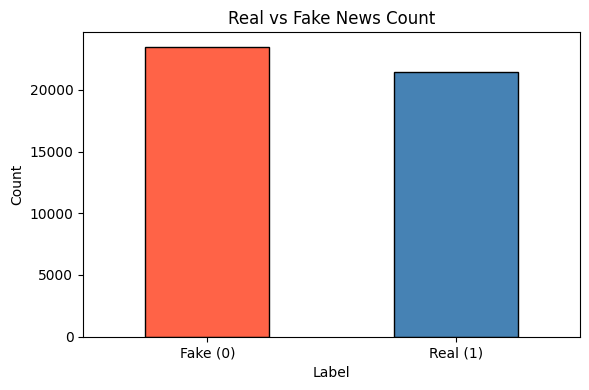

In [9]:
# Bar chart showing class balance
plt.figure(figsize=(6, 4))
df['label'].value_counts().plot(kind='bar', color=['tomato', 'steelblue'], edgecolor='black')
plt.xticks([0, 1], ['Fake (0)', 'Real (1)'], rotation=0)
plt.title('Real vs Fake News Count')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 4.2 News by Subject/Category

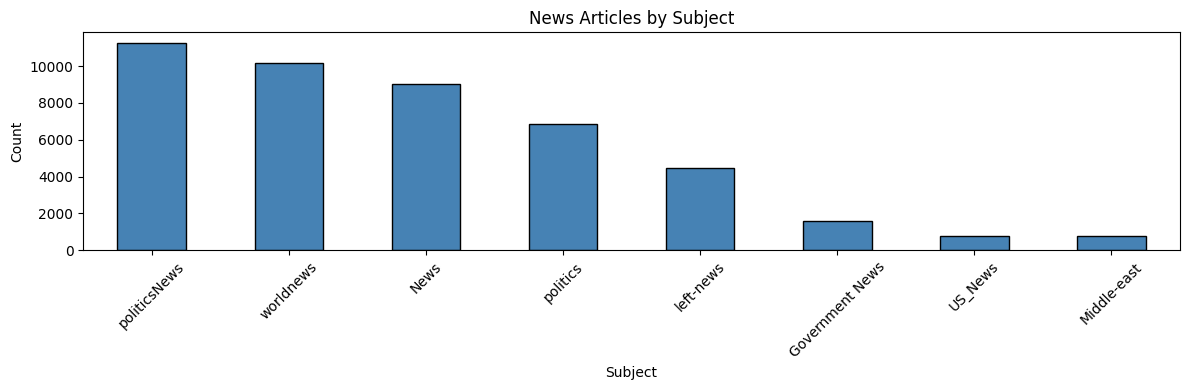

In [10]:
# Check what subjects/topics the news belongs to
plt.figure(figsize=(12, 4))
df['subject'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('News Articles by Subject')
plt.xlabel('Subject')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.3 Subject Distribution: Real vs Fake

<Figure size 1200x500 with 0 Axes>

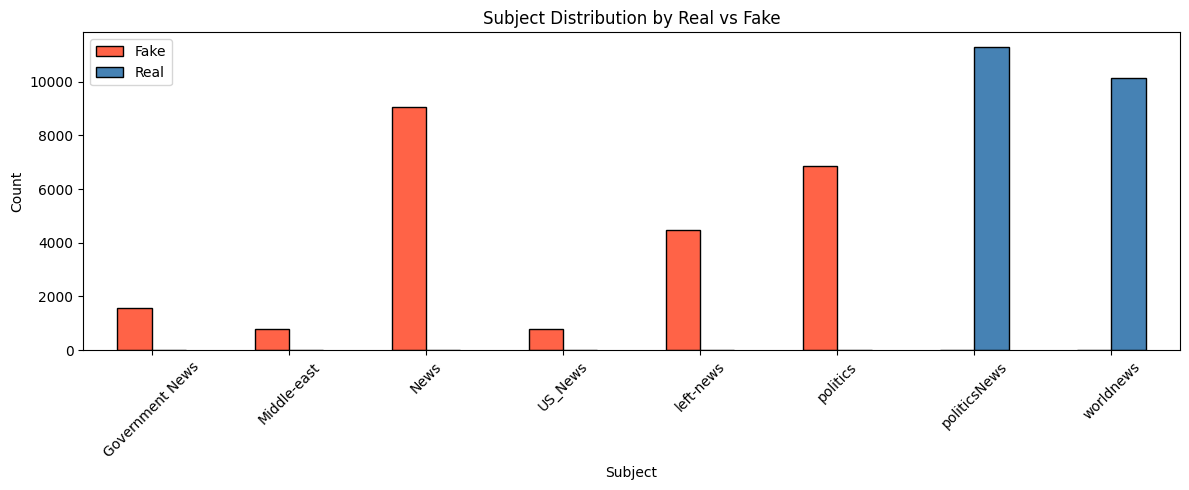

In [11]:
# See which subjects are real or fake
plt.figure(figsize=(12, 5))
subject_label = df.groupby(['subject', 'label']).size().unstack(fill_value=0)
subject_label.plot(kind='bar', figsize=(12, 5), color=['tomato', 'steelblue'], edgecolor='black')
plt.title('Subject Distribution by Real vs Fake')
plt.xlabel('Subject')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(['Fake', 'Real'])
plt.tight_layout()
plt.show()

### 4.4 Title Length Distribution

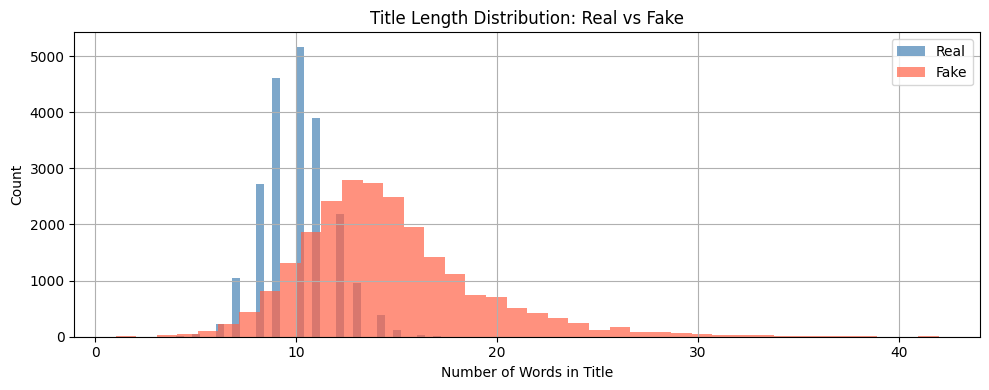

Average title length - Real: 9.95
Average title length - Fake: 14.73


In [12]:
# Add a column for title length (number of words)
df['title_length'] = df['title'].apply(lambda x: len(str(x).split()))

# Plot distribution of title lengths for real vs fake
plt.figure(figsize=(10, 4))
df[df['label'] == 1]['title_length'].hist(bins=40, alpha=0.7, color='steelblue', label='Real')
df[df['label'] == 0]['title_length'].hist(bins=40, alpha=0.7, color='tomato', label='Fake')
plt.title('Title Length Distribution: Real vs Fake')
plt.xlabel('Number of Words in Title')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

print("Average title length - Real:", df[df['label']==1]['title_length'].mean().round(2))
print("Average title length - Fake:", df[df['label']==0]['title_length'].mean().round(2))

## 5. Text Preprocessing


In [29]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = ' '.join([word for word in text.split() if word not in stopwords.words('english')])
    return text

df['clean_title'] = df['title'].apply(clean_text)

# Preview
df[['title', 'clean_title']].head(5)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,title,clean_title
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,breaking gop chairman grassley enough demands ...
1,Failed GOP Candidates Remembered In Hilarious...,failed gop candidates remembered hilarious moc...
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,mike pence new dc neighbors hilariously trolli...
3,California AG pledges to defend birth control ...,california ag pledges defend birth control ins...
4,AZ RANCHERS Living On US-Mexico Border Destroy...,az ranchers living us mexico border destroy na...


## 6. Feature Engineering & Train-Test Split

We use **TF-IDF (Term Frequency - Inverse Document Frequency)** to convert text into numbers.  
It gives higher weight to words that are unique to a document and less weight to common words like "the", "is", etc.

In [30]:
X = df['clean_title']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 35918
Testing samples : 8980


In [31]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2), max_df=0.7)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)

TF-IDF matrix shape (train): (35918, 5000)


## 7. Helper Function — Evaluate Model

In [32]:
def evaluate_model(name, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{'='*45}")
    print(f"  Model: {name}")
    print(f"  Accuracy: {acc*100:.2f}%")
    print(f"{'='*45}")
    print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return acc

## 8. Model Training & Evaluation

I trained three models and compared their accuracy:
- **Logistic Regression** — simple baseline, works well for text
- **Random Forest** — ensemble of decision trees
- **XGBoost** — powerful gradient boosting

### Model 1 — Logistic Regression


  Model: Logistic Regression
  Accuracy: 93.91%
              precision    recall  f1-score   support

        Fake       0.95      0.94      0.94      4669
        Real       0.93      0.94      0.94      4311

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



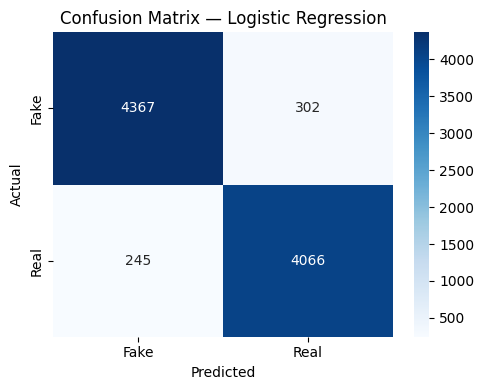

In [33]:
# Logistic Regression is great for text classification
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

pred_lr = lr.predict(X_test_tfidf)
acc_lr = evaluate_model("Logistic Regression", y_test, pred_lr)

### Model 2 — Random Forest


  Model: Random Forest
  Accuracy: 93.31%
              precision    recall  f1-score   support

        Fake       0.93      0.94      0.94      4669
        Real       0.93      0.93      0.93      4311

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980



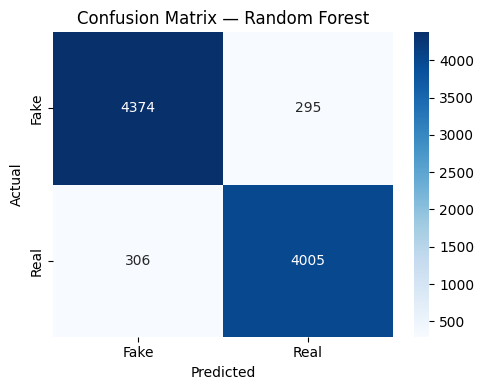

In [34]:
# Random Forest builds many decision trees and takes a majority vote
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_tfidf, y_train)

pred_rf = rf.predict(X_test_tfidf)
acc_rf = evaluate_model("Random Forest", y_test, pred_rf)

### Model 3 — XGBoost


  Model: XGBoost
  Accuracy: 89.81%
              precision    recall  f1-score   support

        Fake       0.95      0.84      0.90      4669
        Real       0.85      0.96      0.90      4311

    accuracy                           0.90      8980
   macro avg       0.90      0.90      0.90      8980
weighted avg       0.90      0.90      0.90      8980



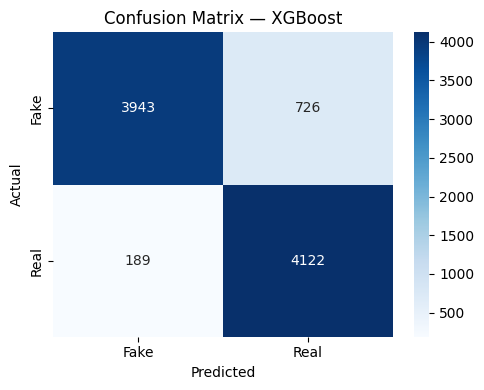

In [35]:
# XGBoost is a gradient boosting algorithm — it builds trees sequentially
xgb = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_tfidf, y_train)

pred_xgb = xgb.predict(X_test_tfidf)
acc_xgb = evaluate_model("XGBoost", y_test, pred_xgb)

## 9. Model Comparison

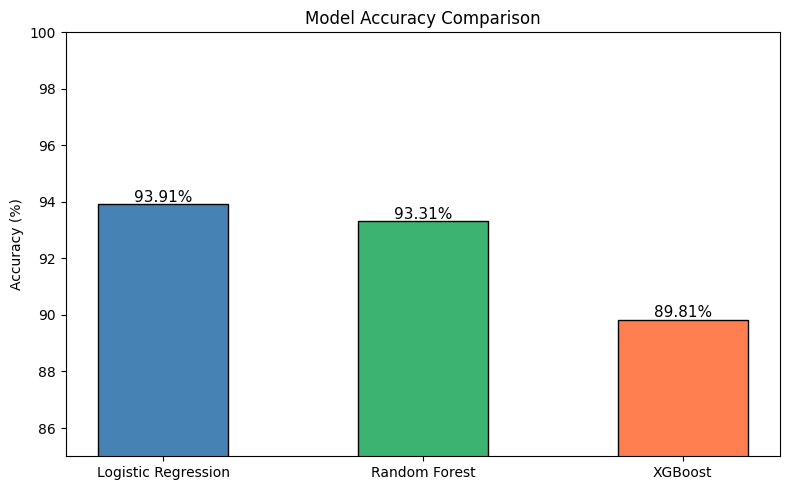

In [36]:
# Compare all three models side by side
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracies = [acc_lr * 100, acc_rf * 100, acc_xgb * 100]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['steelblue', 'mediumseagreen', 'coral'], edgecolor='black', width=0.5)
plt.ylim(85, 100)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{acc:.2f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## 10. Manual Testing

Type any news headline and see what all three models predict.

In [37]:
def predict_news(title):
    # Clean and vectorize the input
    cleaned = clean_text(title)
    vectorized = tfidf.transform([cleaned])

    # Get predictions from all models
    p_lr  = lr.predict(vectorized)[0]
    p_rf  = rf.predict(vectorized)[0]
    p_xgb = xgb.predict(vectorized)[0]

    label_map = {0: " FAKE NEWS", 1: " REAL NEWS"}

    print(f"\nNews Title     : {title}")
    print(f"{'─'*50}")
    print(f"Logistic Regression : {label_map[p_lr]}")
    print(f"Random Forest       : {label_map[p_rf]}")
    print(f"XGBoost             : {label_map[p_xgb]}")
    print(f"{'─'*50}")

In [39]:
# Test with some examples
predict_news("Breaking: President signs new economic relief bill")


News Title     : Breaking: President signs new economic relief bill
──────────────────────────────────────────────────
Logistic Regression :  FAKE NEWS
Random Forest       :  FAKE NEWS
XGBoost             :  FAKE NEWS
──────────────────────────────────────────────────


In [40]:
predict_news("SHOCKING: Government hiding alien invasion from public!!")


News Title     : SHOCKING: Government hiding alien invasion from public!!
──────────────────────────────────────────────────
Logistic Regression :  FAKE NEWS
Random Forest       :  FAKE NEWS
XGBoost             :  FAKE NEWS
──────────────────────────────────────────────────


In [42]:
predict_news("Aliens landed in Delhi and government confirmed it")


News Title     : Aliens landed in Delhi and government confirmed it
──────────────────────────────────────────────────
Logistic Regression :  FAKE NEWS
Random Forest       :  REAL NEWS
XGBoost             :  REAL NEWS
──────────────────────────────────────────────────


## Conclusion

In this project, I built a Fake News Detection system using NLP and machine learning.

Here's a quick summary of what I did:
- Loaded and merged real and fake news datasets, then cleaned the titles
- Used **TF-IDF vectorization** to convert text to numerical features
- Trained and compared **Logistic Regression**, **Random Forest**, and **XGBoost**
- All three models gave strong accuracy — Logistic Regression performed surprisingly well for such a simple model
- Built a **manual testing function** to classify any headline in real time

**Key takeaway:** Text classification doesn't always need complex models. With good preprocessing and TF-IDF, even Logistic Regression can give very high accuracy on this problem.

---
*Project by Prishita Matreja*